# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from impl.utils.explain import vectorize, generate_rules, model_fit, explain, scoring

# Prepare data

In [2]:
from pathlib import Path

projects = [
    "1748884695969-ccea-d240fc", "1748941748026-ccea-b9ac6b", "1748989829337-ccea-4ec741", "1749038770422-ccea-42ed4d",
    "1749777922892-ccea-2c25d2", "1749814642920-ccea-de1f87", "1749886823824-ccea-649444", "1749923655258-ccea-1ba284",
    "1751198102877-ccea-1addfe", "1751208800030-ccea-a4ce3b", "1750185618111-ccea-6e8d47", "1750198943587-ccea-7053fc",
    "1750206690539-ccea-5685b2", "1750216454876-ccea-7d20e2", "1750227193443-ccea-78d6d1", "1750239856908-ccea-022c28",
    "1750251392201-ccea-cf8492", "1750268611439-ccea-719936", "1750277989099-ccea-b24329", "1748920884019-ga-b8096d",
    "1748973401212-ga-159d20", "1749020894373-ga-0c91c0", "1749070990957-ga-e5c457", "1749117177309-ga-e90e3a",
    "1749801622497-ga-1bf740", "1749865564502-ga-d4aeee", "1749911224188-ga-398954", "1749948108048-ga-cf2ad2",
    "1748904187579-rs-eb1239", "1748957118058-rs-2e552d", "1749004788416-rs-6bf5f1", "1749054600895-rs-2ed24b",
    "1749101043616-rs-24f811", "1749789337635-rs-395f0a", "1749825433865-rs-6f42c1", "1749852996207-rs-73049d",
    "1749897744564-rs-122ef9", "1749934847144-rs-a62c00", "1750434085129-ccea-ddb606", "1750449704726-ccea-5b378e",
    "1750463599493-ccea-3174c7", "1750474241344-ccea-de114c", "1750486589729-ccea-d7ee1e", "1750497161663-ccea-e0eee8",
    "1751223236951-ccea-ca103a", "1751231897173-ccea-a652fa", "1751243485332-ccea-36643e", "1751274772053-ccea-ac5042",
    "1750785163861-ccea-21aab6", "1750803393939-ccea-e46291", "1750816760201-ccea-a491e1", "1750840993246-ccea-b56d46",
    "1750864129037-ccea-b6c460", "1750874763838-ccea-c37984", "1751036741158-ccea-8dbdc7", "1751052499693-ccea-37549d",
    "1751064557270-ccea-8d3741", "1751327671761-ccea-fa8901",
]

violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(f"#violations: {len(violations)}, #non-violations: {len(non_violations)}, total: {len(solutions)}")

#violations: 597, #non-violations: 443, total: 1040


# Vectorization

In [3]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

# Train models

In [ ]:
best_model = model_fit(X, y)

2025-08-06 14:24:53,779     INFO   334100 --- 
RANDOMIZED SEARCH
================================================== (explain.py:110)
2025-08-06 14:24:53,781     INFO   334100 --- Search space size (full grid): 240000, using RandomizedSearchCV with 30 iterations... (explain.py:122)
2025-08-06 14:24:53,782     INFO   334100 --- Starting randomized search... (explain.py:136)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-06 14:25:19,180     INFO   334100 --- Randomized search completed! (explain.py:139)
2025-08-06 14:25:19,181     INFO   334100 --- Best CV RMSE: 0.976031 (explain.py:140)
2025-08-06 14:25:19,183     INFO   334100 --- 
Best parameters:
	subsample           : 0.6
	reg_lambda          : 0.5
	reg_alpha           : 0.1
	n_estimators        : 50
	min_child_weight    : 5
	max_depth           : 7
	learning_rate       : 0.05
	colsample_bytree    : 0.7 (explain.py:144)
2025-08-06 14:25:19,184     INFO   334100 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:146)
2025-08-06 14:25:19,200     INFO   334100 --- 
Top 5 parameter combinations:
	1. RMSE: 0.976031 - {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
	2. RMSE: 0.981840 - {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 3, 'max_de

tostring() is deprecated. Use tobytes() instead.


2025-08-06 14:25:19,675     INFO   334100 --- Cross-validation RMSE: 0.976031 (+/- 0.691395) (explain.py:189)
2025-08-06 14:25:19,685     INFO   334100 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754504719677/best_model.pkl'. (explain.py:196)
2025-08-06 14:25:19,690     INFO   334100 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754504719677/grid_search_results.pkl'. (explain.py:201)
2025-08-06 14:25:19,691     INFO   334100 --- 
MODEL VISUALIZATION
================================================== (explain.py:203)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.


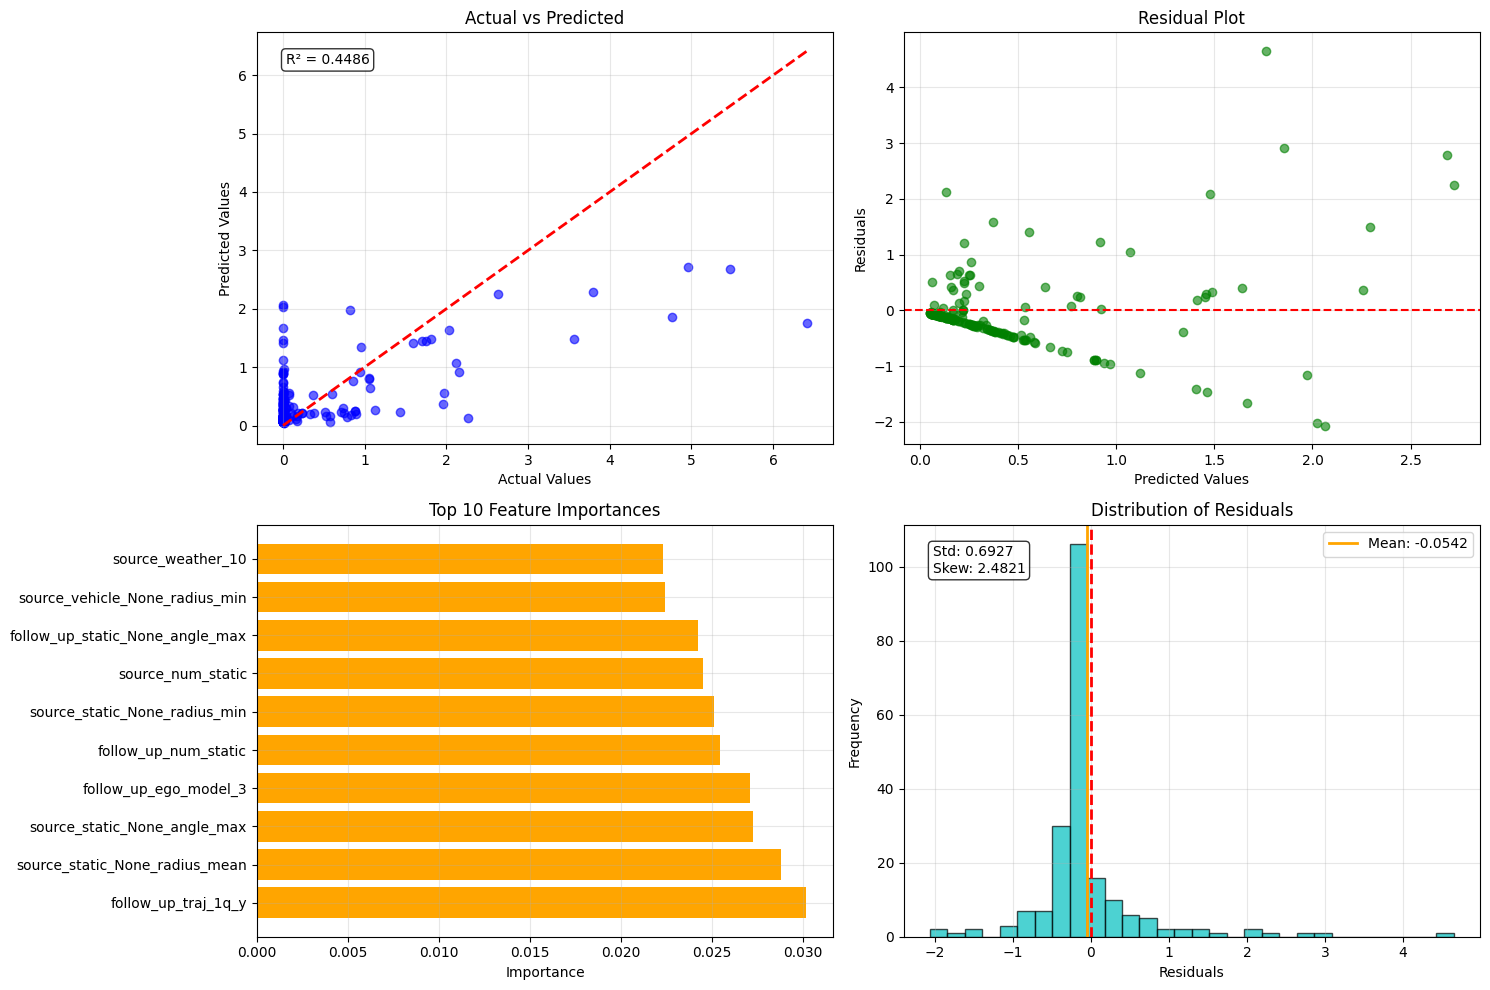

In [12]:
best_model_v1 = model_fit(X, y_v1)

2025-08-06 15:10:36,650     INFO   334100 --- 
RANDOMIZED SEARCH
================================================== (explain.py:110)
2025-08-06 15:10:36,651     INFO   334100 --- Search space size (full grid): 240000, using RandomizedSearchCV with 30 iterations... (explain.py:122)
2025-08-06 15:10:36,652     INFO   334100 --- Starting randomized search... (explain.py:136)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-06 15:11:01,767     INFO   334100 --- Randomized search completed! (explain.py:139)
2025-08-06 15:11:01,769     INFO   334100 --- Best CV RMSE: 0.887809 (explain.py:140)
2025-08-06 15:11:01,770     INFO   334100 --- 
Best parameters:
	subsample           : 0.6
	reg_lambda          : 2.0
	reg_alpha           : 1.0
	n_estimators        : 100
	min_child_weight    : 5
	max_depth           : 7
	learning_rate       : 0.01
	colsample_bytree    : 0.8 (explain.py:144)
2025-08-06 15:11:01,771     INFO   334100 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:146)
2025-08-06 15:11:01,775     INFO   334100 --- 
Top 5 parameter combinations:
	1. RMSE: 0.887809 - {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
	2. RMSE: 0.892979 - {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 7, 'max_

tostring() is deprecated. Use tobytes() instead.


2025-08-06 15:11:02,580     INFO   334100 --- Cross-validation RMSE: 0.887809 (+/- 0.543765) (explain.py:189)
2025-08-06 15:11:02,587     INFO   334100 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754507462582/best_model.pkl'. (explain.py:196)
2025-08-06 15:11:02,593     INFO   334100 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754507462582/grid_search_results.pkl'. (explain.py:201)
2025-08-06 15:11:02,594     INFO   334100 --- 
MODEL VISUALIZATION
================================================== (explain.py:203)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.


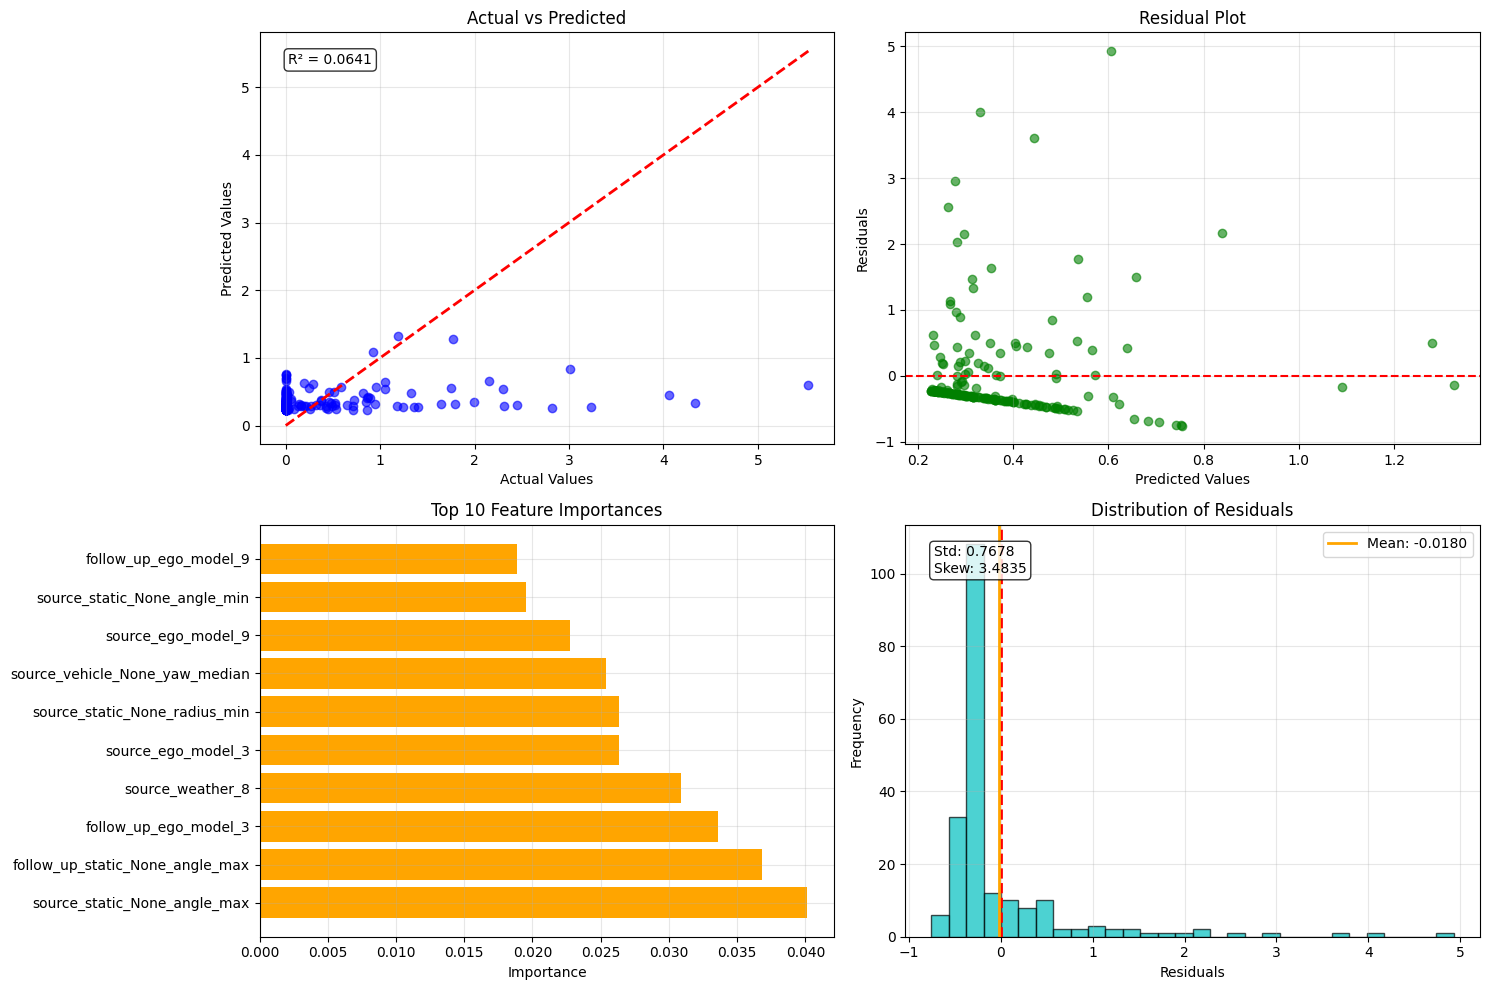

In [14]:
best_model_v2 = model_fit(X, y_v2)

# Load models

In [36]:
import joblib

best_model = joblib.load("out/exp_results/1752513402321/best_model.pkl")
# GBDT
# best_model_v1 = joblib.load("out/exp_results/1751041555795/best_model.pkl")
# best_model_v2 = joblib.load("out/exp_results/1751042068929/best_model.pkl")
# XgBoost
best_model_v1 = joblib.load("out/exp_results/1754504719677/best_model.pkl")
best_model_v2 = joblib.load("out/exp_results/1754507462582/best_model.pkl")

# RuleFit

In [144]:
rulefit = generate_rules(X, y, features)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("importance", ascending=False).style.background_gradient(cmap="viridis")

,rule,type,coef,support,importance
496,source_traj_3q_y > -57.11176 and source_static_None_yaw_median > -106.37935 and follow_up_traj_middle_y > -68.72901 and follow_up_vehicle_None_yaw_max > -85.93185,rule,0.289968,0.789423,0.118225
497,source_num_static <= 8.0 and follow_up_traj_1q_yaw > -439.95219 and source_ego_model_21 <= 0.5,rule,0.332054,0.916346,0.091935
493,follow_up_traj_end_y <= 63.85935 and follow_up_ego_model_18 <= 0.5 and source_traj_1q_y > -62.79263,rule,0.217905,0.926923,0.056713
501,follow_up_traj_1q_y > -64.5007 and follow_up_traj_1q_yaw <= -269.18712 and follow_up_num_static <= 17.5,rule,0.047544,0.136538,0.016325
500,source_traj_1q_yaw > -449.72627 and source_traj_middle_y > -31.7143 and follow_up_num_static > 0.5 and follow_up_static_None_yaw_min > -158.18532,rule,0.031306,0.445192,0.015558
495,source_vehicle_None_speed_min <= 7.17654 and follow_up_traj_end_z <= 0.04702,rule,0.026369,0.867308,0.008945
498,source_traj_middle_y > -40.99794 and source_traj_end_x <= 99.44237 and source_num_vehicle <= 9.5 and source_ego_model_6 <= 0.5 and follow_up_traj_1q_z > -0.05545 and follow_up_traj_1q_yaw > -360.73563 and follow_up_traj_middle_y > -0.00562 and follow_up_traj_3q_z <= 0.02773 and follow_up_static_None_angle_max <= 150.78525 and source_weather_1 <= 0.5,rule,0.013774,0.390385,0.006720
494,follow_up_ego_yaw <= 179.80878 and follow_up_traj_end_yaw <= 359.99997,rule,0.022687,0.927885,0.005869
499,source_weather_7 <= 0.5 and follow_up_traj_middle_yaw > -449.64967,rule,0.019580,0.903846,0.005772
492,follow_up_ego_yaw > 90.33326,rule,-0.000124,0.212500,0.000051


# SHAP

In [ ]:
explanation = explain(best_model, X)

# RQ4: MASE comparison

In [4]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

metrics = defaultdict(lambda: defaultdict(list))
for _ in range(500):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    # Baseline
    y_pred_median = np.full_like(y_val, fill_value=np.median(y_train))
    metrics["baseline"]["mae"].append(mean_absolute_error(y_val, y_pred_median))

    # RuleFit
    rulefit = RuleFitRegressor()
    rulefit.fit(X_train, y_train)
    y_pred_rulefit = rulefit.predict(X_val)
    mae_rulefit = mean_absolute_error(y_val, y_pred_rulefit)
    metrics["rulefit"]["mae"].append(mae_rulefit)
    metrics["rulefit"]["mase"].append(mae_rulefit / mean_absolute_error(y_val, y_pred_median))

    rules = rulefit._get_rules()
    rules = rules[rules.coef != 0]
    metrics["rulefit"]["rule"].append(rules)

    # Random Forest
    rf = RandomForestRegressor()
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_val, y_pred_rf)
    metrics["rf"]["mae"].append(mae_rf)
    metrics["rf"]["mase"].append(mae_rf / mean_absolute_error(y_val, y_pred_median))
    metrics["rf"]["leaves"].append(sum(est.tree_.n_leaves for est in rf.estimators_))

    # GBDT
    gbdt = GradientBoostingRegressor()
    gbdt.fit(X_train, y_train)
    y_pred_gbdt = gbdt.predict(X_val)
    mae_gbdt = mean_absolute_error(y_val, y_pred_gbdt)
    metrics["gbdt"]["mae"].append(mae_gbdt)
    metrics["gbdt"]["mase"].append(mae_gbdt / mean_absolute_error(y_val, y_pred_median))
    metrics["gbdt"]["leaves"].append(sum(est[0].tree_.n_leaves for est in gbdt.estimators_))

with open("out/mase.pkl", "wb") as f:
    pickle.dump(dict(metrics), f)

In [4]:
with open("out/mase.pkl", "rb") as f:
    metrics = pickle.load(f)

Average MASE of RuleFit: 1.200911707892944
Average MASE of RF: 1.2527705489343322
Average MASE of GBDT: 1.1760611259721576


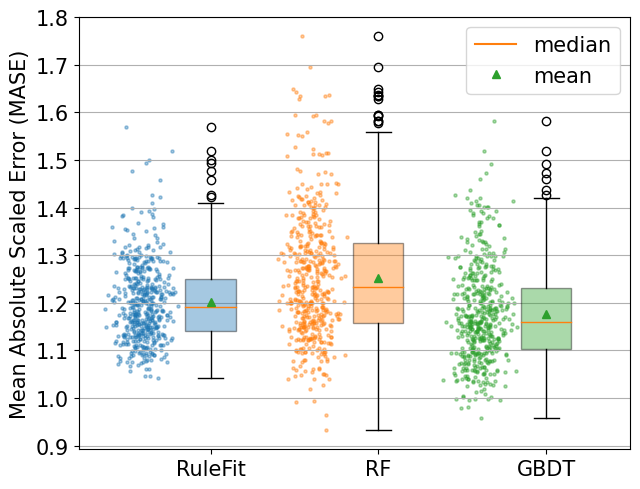

In [57]:
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
labels = ["RuleFit", "RF", "GBDT"]
values = [metrics[alg.lower()]["mase"] for alg in labels]
for alg in labels:
    print(f"Average MASE of {alg}: {np.mean(metrics[alg.lower()]['mase'])}")
bplot = ax.boxplot(values, labels=labels, showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], [f"C{i}" for i in range(10)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, value in enumerate(values):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, alpha=0.4, s=5)
ax.grid(axis="y")
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylabel("Mean Absolute Scaled Error (MASE)", fontsize=text_size)
ax.legend(handles=[
    Line2D([0], [0], c="C1", label="median"),
    Line2D([0], [0], ls="None", marker="^", mfc="C2", mec="C2", label="mean")
], fontsize=text_size)
plt.tight_layout()
plt.savefig("out/visualizations/mase.png")

In [24]:
print(f"Average number of rules in RuleFit: {np.mean([len(rule_df) for rule_df in metrics['rulefit']['rule']]):.2f}")
print(f"Average number of rules in RF: {np.mean(metrics['rf']['leaves']):.2f}")
print(f"Average number of rules in GBDT: {np.mean(metrics['gbdt']['leaves']):.2f}")

Average number of rules in RuleFit: 28.63
Average number of rules in RF: 35068.00
Average number of rules in GBDT: 725.62


# RQ4: Support for the rules

In [5]:
ny = np.array(y)
X_vio = X[ny != 0]
support = []
for rule_df in metrics["rulefit"]["rule"]:
    non_linear_rules = rule_df[rule_df.type != "linear"]
    unique = set()
    for i, row in non_linear_rules.iterrows():
        rule = row["rule"]
        satisfied = X_vio.query(rule)
        unique |= set(satisfied.index)
    support.append(len(unique) / len(X_vio))

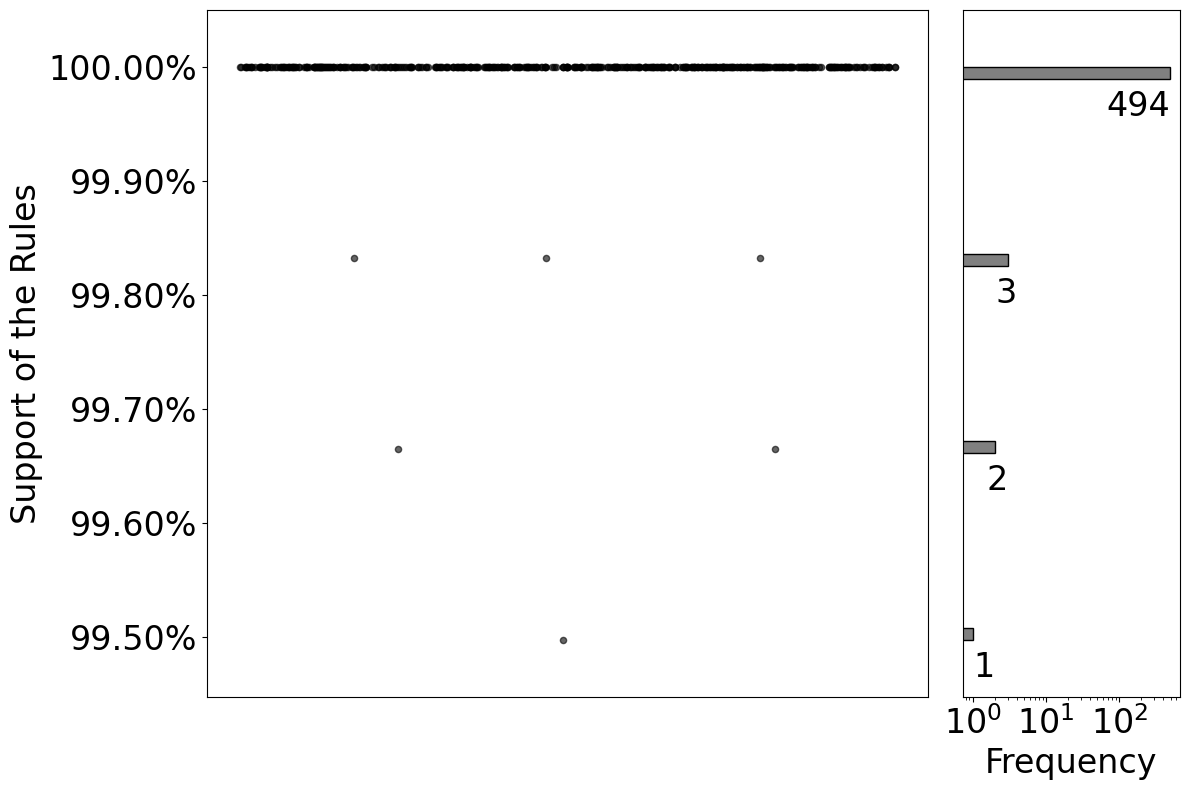

In [60]:
from matplotlib.ticker import PercentFormatter

data_x = np.random.rand(len(support))
data_y = np.array(support)
y_min = np.min(data_y)
y_max = np.max(data_y)

height = 8
text_size, tick_size = height * 3, height * 3
fig = plt.figure(figsize=(height * 1.5, height))
ax_scatter = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=4)
ax_hist_y = plt.subplot2grid((4, 4), (0, 3), rowspan=4)

ax_scatter.scatter(data_x, data_y, c="k", marker="o", s=20, alpha=0.6)
ax_scatter.set_ylabel("Support of the Rules", fontsize=text_size)
padding = 0.0005
ax_scatter.set_ylim(y_min - padding, y_max + padding)
ax_scatter.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_scatter.set_xticks([])
ax_scatter.tick_params(labelsize=tick_size)

hist, bin_edges, _ = ax_hist_y.hist(data_y, bins=np.linspace(y_min, y_max, 50),
                                    orientation="horizontal", log=True,
                                    color="gray", edgecolor="black")
ax_hist_y.set_ylim(y_min - padding, y_max + padding)
ax_hist_y.set_yticks([])
ax_hist_y.tick_params(labelsize=tick_size)
for i, (count, bin_edge) in enumerate(zip(hist, bin_edges[:-1])):
    if count > 0:
        ax_hist_y.text(count + 1, bin_edge - 0.0001, f"{int(count)}", c="black",
                       va="top", ha="right", fontsize=tick_size)
ax_hist_y.set_xlabel("Frequency", fontsize=text_size)
plt.tight_layout()
plt.savefig("out/visualizations/support.png")

# RQ4: Consistency of importance

In [37]:
score, D, W = scoring(best_model_v1, best_model_v2, X)
score

NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT_ARRAY2, or NPY_ARRAY_INOUT_FARRAY2 respectively instead, and call PyArray_ResolveWritebackIfCopy before the array is deallocated, i.e. before the last call to Py_DECREF.
UPDATEIFCOPY detected in array_dealloc.  Required call to PyArray_ResolveWritebackIfCopy or PyArray_DiscardWritebackIfCopy is missing
NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT_ARRAY2, or NPY_ARRAY_INOUT_FARRAY2 respectively instead, and call PyArray_ResolveWritebackIfCopy before the array is deallocated, i.e. before the last call to Py_DECREF.
UPDATEIFCOPY detected in array_dealloc.  Required call to PyArray_ResolveWritebackIfCopy or PyArray_DiscardWritebackIfCopy is missing
NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT

16.771198

In [38]:
feature_importance = abs(W * D).mean(axis=0)
shap_rank = (pd.DataFrame({"feature": features, "importance": feature_importance})
             .sort_values(by="importance", ascending=False))
top_k_overlaps = []
for top_k in range(1, 31):
    overlaps = []
    for rule_df in metrics["rulefit"]["rule"]:
        rulefit_rank = rule_df[rule_df.type != "linear"].sort_values("importance", ascending=False).reset_index()
        rank = []
        for _, row in shap_rank.head(top_k).iterrows():
            rank.append(rulefit_rank["rule"].str.contains(row["feature"]).idxmax() + 1)
        overlaps.append(sum(1 for r in rank if r <= top_k) / top_k)
    top_k_overlaps.append(overlaps)

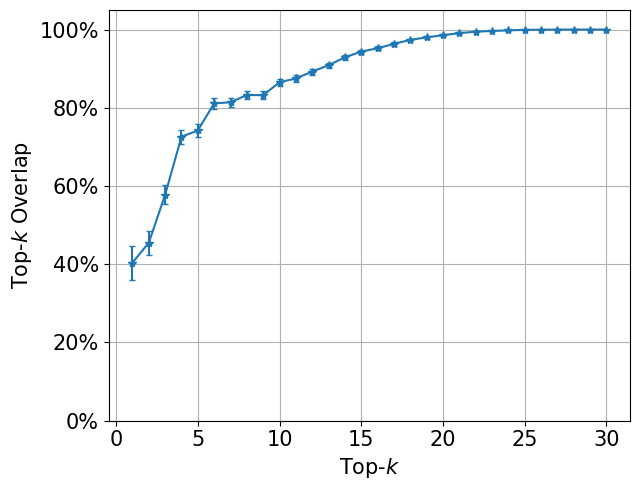

In [53]:
height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
ax.errorbar(np.arange(1, 31), np.mean(top_k_overlaps, axis=1),
            yerr=1.96 * np.std(top_k_overlaps, axis=1, ddof=1) / np.sqrt(len(top_k_overlaps[0])),
            fmt="*-C0", capsize=2)
ax.grid()
ax.set_xlabel("Top-$k$", fontsize=text_size)
ax.set_ylabel("Top-$k$ Overlap", fontsize=text_size)
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("out/visualizations/top_k_overlap.png")

# Most important rules and features

In [61]:
pd.concat(metrics["rulefit"]["rule"]).sort_values("importance", ascending=False)

,rule,type,coef,support,importance
506,source_traj_middle_y > -68.72901 and source_st...,rule,0.49846,0.78005,0.20647
506,follow_up_traj_1q_y > -50.38745 and source_ego...,rule,0.74198,0.92788,0.19193
510,follow_up_ego_yaw <= 179.80878 and follow_up_t...,rule,0.47319,0.79567,0.19079
509,source_weather_7 <= 0.5 and source_num_static ...,rule,0.45517,0.78726,0.18628
499,source_num_static <= 17.5 and follow_up_ego_mo...,rule,0.72178,0.93029,0.18381
...,...,...,...,...,...
73,follow_up_ego_model_7,linear,0.00000,1.00000,0.00000
301,follow_up_traj_middle_x,linear,-0.00000,1.00000,0.00000
301,follow_up_traj_middle_x,linear,-0.00000,1.00000,0.00000
302,follow_up_traj_middle_y,linear,0.00000,1.00000,0.00000


In [62]:
pd.DataFrame({"feature": features, "importance": abs(W * D).mean(axis=0)}).sort_values("importance", ascending=False)

,feature,importance
41,source_ego_model_21,0.00531
102,source_traj_middle_y,0.00466
101,source_traj_middle_x,0.00210
280,source_static_None_radius_min,0.00202
38,source_ego_model_18,0.00184
...,...,...
238,source_walker_None_yaw_median,0.00000
237,source_walker_None_yaw_mean,0.00000
236,source_walker_None_yaw_max,0.00000
235,source_walker_None_yaw_min,0.00000


# RAD comparison

In [7]:
def _evaluate_rules(_rules, _X, _y):
    _y = np.array(_y)
    for _i, _row in _rules[(_rules.coef != 0) & (_rules.type != "linear")].iterrows():
        _rule = _row["rule"]
        _rulefit_mask = np.zeros(_y.size, dtype=bool)
        _rulefit_mask[_X.query(_rule).index] = True
        _rulefit_diff = _y[_rulefit_mask].mean() - _y[~_rulefit_mask].mean()
        _rulefit_score = np.sign(_rulefit_diff * _row["coef"]) * np.abs(_rulefit_diff - _row["coef"])
        rules.loc[_i, "score_rulefit"] = _rulefit_score
        rules.loc[_i, "diff_rulefit"] = _rulefit_diff

        _n = len(_y)
        _base_mask = np.array([True] * (_n // 2) + [False] * (_n - _n // 2))
        _rand_diff = 0
        _times = 1000
        for _ in range(_times):
            _rand_mask = np.random.permutation(_base_mask)
            _rand_diff += _y[_rand_mask].mean() - _y[~_rand_mask].mean()
        _rand_diff /= _times
        _rand_score = np.sign(_rand_diff * _row["coef"]) * np.abs(_rand_diff - _row["coef"])
        rules.loc[_i, "score_random"] = _rand_score
        rules.loc[_i, "diff_random"] = _rand_diff

In [51]:
dfs = []
for _ in range(500):
    rulefit = generate_rules(X, y, features)
    rules = rulefit._get_rules()
    _evaluate_rules(rules, X, y)
    dfs.append(rules)
df = pd.concat(dfs)
df = df[(df.coef != 0) & (df.type != "linear")]

with open("out/rad.pkl", "wb") as f:
    pickle.dump(df, f)

In [8]:
with open("out/rad.pkl", "rb") as f:
    df = pickle.load(f)

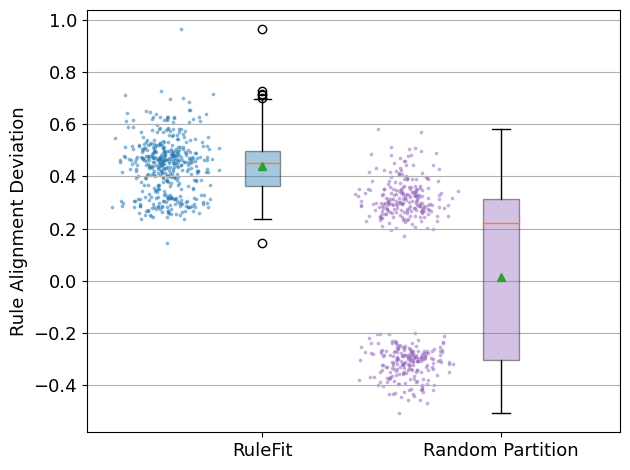

In [9]:
fig, ax = plt.subplots()
sorted_df = df.sort_values("importance", ascending=False).head(len(df) // 10)
values = [sorted_df["score_rulefit"], sorted_df["score_random"]]
bplot = ax.boxplot(values, labels=["RuleFit", "Random Partition"], showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], ("C0", "C4")):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, (value, color) in enumerate(zip(values, ("C0", "C4"))):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, color=color, alpha=0.4, s=3)
ax.grid(axis="y")
ax.tick_params(labelsize=13)
ax.set_ylabel("Rule Alignment Deviation", fontsize=13)
plt.tight_layout()
plt.savefig("out/visualizations/rcd.png")